#### Packages

In [2]:
## Common Packages
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize)
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## Packages for this assignment
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score as f1
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from sklearn.metrics.pairwise import euclidean_distances
from ISLP.cluster import compute_linkage
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel as ets 
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.graphics.tsaplots import plot_pacf 
from statsmodels.tsa.arima.model import ARIMA 
from scipy.stats import kstest
from sklearn.preprocessing import PolynomialFeatures

from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns

import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import random
random.seed(0)

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize)
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score as f1
import statsmodels 
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
import sklearn.model_selection as skm

# San Francisco Crime Classification

In [18]:
Crime = pd.read_csv('trainClass.csv')
Crime

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541
...,...,...,...,...,...,...,...,...,...
878044,2003-01-06 00:15:00,ROBBERY,ROBBERY ON THE STREET WITH A GUN,Monday,TARAVAL,NONE,FARALLONES ST / CAPITOL AV,-122.459033,37.714056
878045,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,INGLESIDE,NONE,600 Block of EDNA ST,-122.447364,37.731948
878046,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,SOUTHERN,NONE,5TH ST / FOLSOM ST,-122.403390,37.780266
878047,2003-01-06 00:01:00,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM OF VEHICLES",Monday,SOUTHERN,NONE,TOWNSEND ST / 2ND ST,-122.390531,37.780607


In [4]:
Crime = pd.read_csv('trainClass.csv')
Crime = Crime.sample(frac=.2)
CrimeTest = pd.read_csv('testClass.csv')
Crime

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
436120,2009-03-21 16:37:00,ASSAULT,BATTERY,Saturday,INGLESIDE,NONE,MISSION ST / SILVER AV,-122.431295,37.728730
565197,2007-05-19 00:01:00,NON-CRIMINAL,"DEATH REPORT, CAUSE UNKNOWN",Saturday,CENTRAL,NONE,600 Block of GEARY ST,-122.414011,37.786677
718394,2005-03-10 15:30:00,BURGLARY,"BURGLARY, UNLAWFUL ENTRY",Thursday,RICHMOND,NONE,500 Block of JOHNFKENNEDY DR,-122.466205,37.772541
366619,2010-04-07 19:55:00,ASSAULT,BATTERY,Wednesday,INGLESIDE,"ARREST, BOOKED",100 Block of BROOKDALE AV,-122.420891,37.712092
220953,2012-05-31 17:09:00,SECONDARY CODES,DOMESTIC VIOLENCE,Thursday,INGLESIDE,"ARREST, BOOKED",0 Block of JOOST AV,-122.436851,37.732435
...,...,...,...,...,...,...,...,...,...
555857,2007-07-11 04:39:00,RECOVERED VEHICLE,RECOVERED VEHICLE - STOLEN OUTSIDE SF,Wednesday,INGLESIDE,NONE,200 Block of BLYTHDALE AV,-122.420557,37.710895
753244,2004-09-01 22:00:00,LARCENY/THEFT,PETTY THEFT FROM UNLOCKED AUTO,Wednesday,NORTHERN,NONE,1300 Block of STEINER ST,-122.434138,37.781685
305898,2011-02-25 22:00:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Friday,BAYVIEW,NONE,SILVER AV / BRUSSELS ST,-122.407539,37.731847
11497,2015-03-18 18:10:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,INGLESIDE,NONE,BOSWORTH ST / ROUSSEAU ST,-122.430280,37.733312


In [5]:
CrimeTest

,Id,Dates,DayOfWeek,PdDistrict,Address,X,Y
0,0,2015-05-10 23:59:00,Sunday,BAYVIEW,2000 Block of THOMAS AV,-122.399588,37.735051
1,1,2015-05-10 23:51:00,Sunday,BAYVIEW,3RD ST / REVERE AV,-122.391523,37.732432
2,2,2015-05-10 23:50:00,Sunday,NORTHERN,2000 Block of GOUGH ST,-122.426002,37.792212
3,3,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
4,4,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
...,...,...,...,...,...,...,...
884257,884257,2003-01-01 00:01:00,Wednesday,MISSION,2600 Block of BRYANT ST,-122.408983,37.751987
884258,884258,2003-01-01 00:01:00,Wednesday,NORTHERN,1900 Block of WASHINGTON ST,-122.425342,37.792681
884259,884259,2003-01-01 00:01:00,Wednesday,INGLESIDE,5500 Block of MISSION ST,-122.445418,37.712075
884260,884260,2003-01-01 00:01:00,Wednesday,BAYVIEW,1500 Block of HUDSON AV,-122.387394,37.739479


In [6]:
Crime = pd.get_dummies(Crime,columns=['DayOfWeek', 'PdDistrict'], drop_first = False)
CrimeTest = pd.get_dummies(CrimeTest,columns=['DayOfWeek', 'PdDistrict'], drop_first = False)
Crime[:3]

,Dates,Category,Descript,Resolution,Address,X,Y,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,...,PdDistrict_BAYVIEW,PdDistrict_CENTRAL,PdDistrict_INGLESIDE,PdDistrict_MISSION,PdDistrict_NORTHERN,PdDistrict_PARK,PdDistrict_RICHMOND,PdDistrict_SOUTHERN,PdDistrict_TARAVAL,PdDistrict_TENDERLOIN
436120,2009-03-21 16:37:00,ASSAULT,BATTERY,NONE,MISSION ST / SILVER AV,-122.431295,37.728730,False,False,True,...,False,False,True,False,False,False,False,False,False,False
565197,2007-05-19 00:01:00,NON-CRIMINAL,"DEATH REPORT, CAUSE UNKNOWN",NONE,600 Block of GEARY ST,-122.414011,37.786677,False,False,True,...,False,True,False,False,False,False,False,False,False,False
718394,2005-03-10 15:30:00,BURGLARY,"BURGLARY, UNLAWFUL ENTRY",NONE,500 Block of JOHNFKENNEDY DR,-122.466205,37.772541,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [7]:
CrimeCats = sorted(list(set(Crime['Category'])))
CrimeCats

['ARSON',
 'ASSAULT',
 'BAD CHECKS',
 'BRIBERY',
 'BURGLARY',
 'DISORDERLY CONDUCT',
 'DRIVING UNDER THE INFLUENCE',
 'DRUG/NARCOTIC',
 'DRUNKENNESS',
 'EMBEZZLEMENT',
 'EXTORTION',
 'FAMILY OFFENSES',
 'FORGERY/COUNTERFEITING',
 'FRAUD',
 'GAMBLING',
 'KIDNAPPING',
 'LARCENY/THEFT',
 'LIQUOR LAWS',
 'LOITERING',
 'MISSING PERSON',
 'NON-CRIMINAL',
 'OTHER OFFENSES',
 'PORNOGRAPHY/OBSCENE MAT',
 'PROSTITUTION',
 'RECOVERED VEHICLE',
 'ROBBERY',
 'RUNAWAY',
 'SECONDARY CODES',
 'SEX OFFENSES FORCIBLE',
 'SEX OFFENSES NON FORCIBLE',
 'STOLEN PROPERTY',
 'SUICIDE',
 'SUSPICIOUS OCC',
 'TRESPASS',
 'VANDALISM',
 'VEHICLE THEFT',
 'WARRANTS',
 'WEAPON LAWS']

In [8]:
Predictors = list(Crime.columns)

Predictors.remove('Category')
Predictors.remove('Dates')
Predictors.remove('Descript')
Predictors.remove('Resolution')
Predictors.remove('Address')
Predictors

['X',
 'Y',
 'DayOfWeek_Friday',
 'DayOfWeek_Monday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'PdDistrict_BAYVIEW',
 'PdDistrict_CENTRAL',
 'PdDistrict_INGLESIDE',
 'PdDistrict_MISSION',
 'PdDistrict_NORTHERN',
 'PdDistrict_PARK',
 'PdDistrict_RICHMOND',
 'PdDistrict_SOUTHERN',
 'PdDistrict_TARAVAL',
 'PdDistrict_TENDERLOIN']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(Crime[Predictors], Crime['Category'], random_state=0, test_size=0.2)
feature_names = list(X_train.columns)
X_train.shape


(140488, 19)

### Decision Tree

0.34330334263424633
0.19554721835903366
|--- PdDistrict_TENDERLOIN <= 0.50
|   |--- Y <= 37.76
|   |   |--- X <= -122.42
|   |   |   |--- Y <= 37.72
|   |   |   |   |--- X <= -122.47
|   |   |   |   |   |--- X <= -122.47
|   |   |   |   |   |   |--- Y <= 37.72
|   |   |   |   |   |   |   |--- X <= -122.50
|   |   |   |   |   |   |   |   |--- DayOfWeek_Monday <= 0.50
|   |   |   |   |   |   |   |   |   |--- DayOfWeek_Tuesday <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- Y <= 37.72
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- Y >  37.72
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |--- DayOfWeek_Tuesday >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.

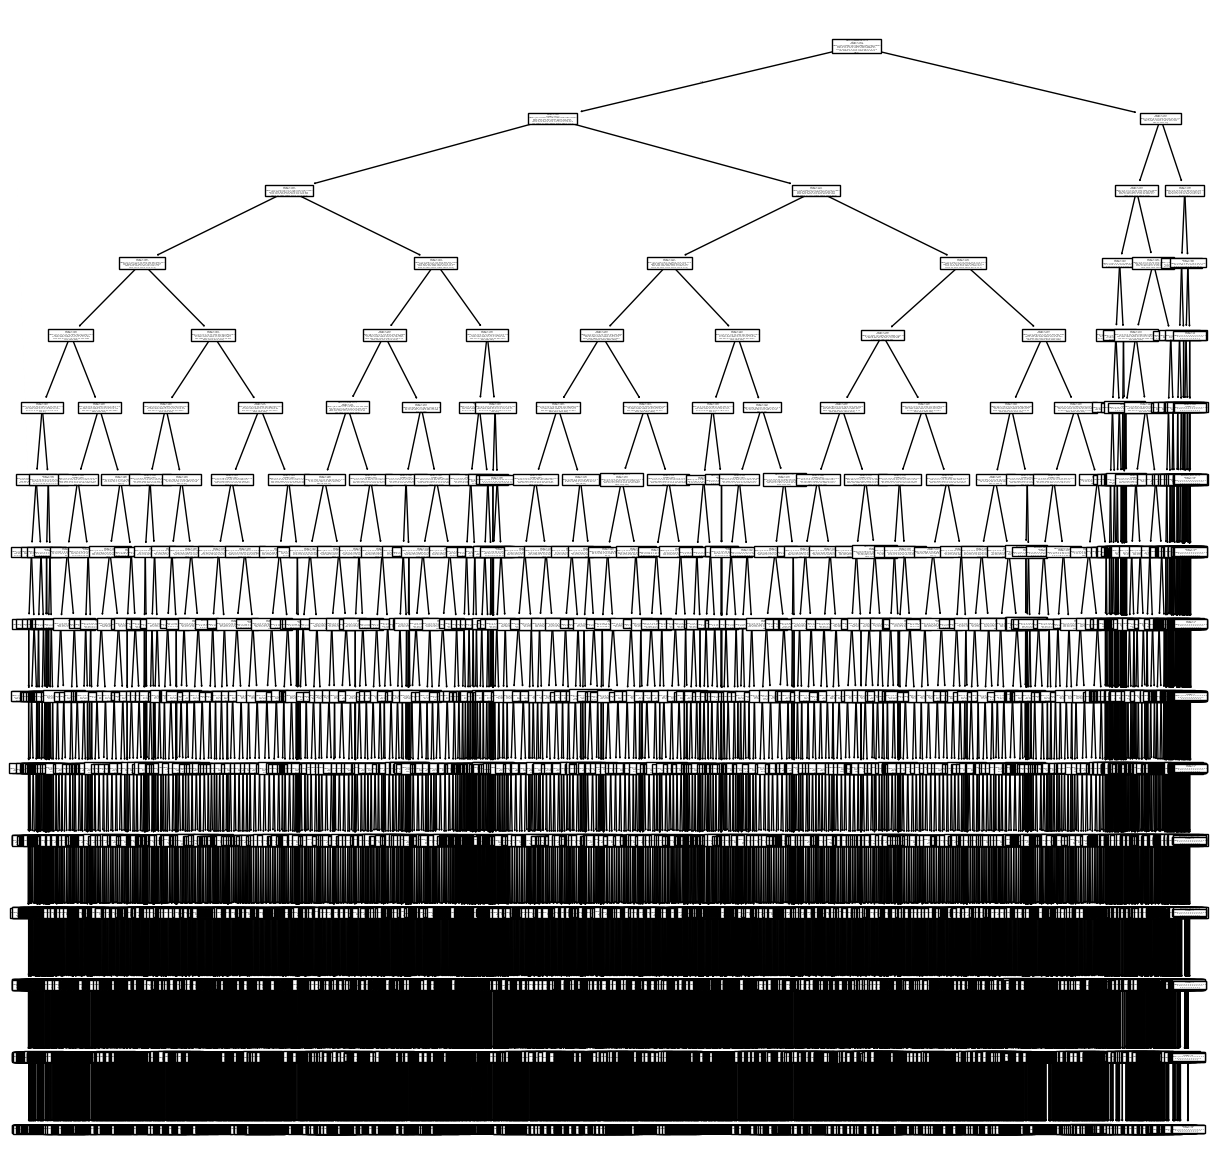

In [8]:
clf = DTC(criterion='entropy',
          max_depth=15,
          random_state=0)        
clf.fit(X_train, Y_train)

print(accuracy_score(Y_train, clf.predict(X_train)))
print(f1(Y_train, clf.predict(X_train), average = 'macro'))


ax = subplots(figsize=(15,15))[1]
plot_tree(clf,
          feature_names=feature_names,
          ax=ax);

print(export_text(clf,
                  feature_names=feature_names,
                  show_weights=True))

In [9]:
print("test: ", accuracy_score(Y_test,
                     clf.predict(X_test)))
print(f1(Y_test, clf.predict(X_test), average = 'macro'))

y_hat_dt = clf.predict(X_train)
print("train: ", np.mean((Y_train == y_hat_dt)))
print(f1(Y_train, y_hat_dt, average = 'macro'))

confusion = confusion_table(clf.predict(X_test),
                            Y_test)
confusion

test:  0.24782187802516942
0.07862403664288294
train:  0.34330334263424633
0.19554721835903366


Truth,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,...,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
Predicted,,,,,,,,,,,,,,,,,,,,,
ARSON,0,0,0,0,2,0,0,1,1,0,...,0,0,1,0,1,0,1,1,1,0
ASSAULT,7,555,1,4,143,21,6,216,17,1,...,34,0,18,2,173,31,234,213,201,79
BAD CHECKS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRIBERY,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
BURGLARY,1,53,0,0,65,2,0,18,2,0,...,6,0,4,2,32,6,47,54,25,2
DISORDERLY CONDUCT,0,1,0,0,3,1,0,2,0,0,...,0,0,1,0,3,2,5,2,4,2
DRIVING UNDER THE INFLUENCE,0,2,0,0,3,0,1,1,0,0,...,1,0,0,1,1,0,1,2,2,1
DRUG/NARCOTIC,4,240,0,0,40,32,1,870,18,0,...,7,0,15,1,79,31,65,50,314,30
DRUNKENNESS,0,1,1,0,2,0,0,1,2,1,...,0,0,0,0,0,0,2,1,3,0


In [10]:
clf.predict_proba(CrimeTest[Predictors])

array([[0.01020408, 0.17857143, 0.        , ..., 0.10204082, 0.0255102 ,
        0.00510204],
       [0.        , 0.14237288, 0.        , ..., 0.03389831, 0.0440678 ,
        0.03050847],
       [0.        , 0.03875969, 0.00775194, ..., 0.10852713, 0.00775194,
        0.        ],
       ...,
       [0.        , 0.04166667, 0.        , ..., 0.125     , 0.        ,
        0.        ],
       [0.        , 0.14556962, 0.        , ..., 0.03797468, 0.06962025,
        0.01265823],
       [0.        , 0.03658537, 0.        , ..., 0.        , 0.08536585,
        0.        ]])

In [11]:
crime_level = pd.DataFrame(clf.predict_proba(CrimeTest[Predictors]), columns = CrimeCats)
#print(crime_level)

output = pd.DataFrame(CrimeTest['Id'])
output = pd.concat([output, crime_level], axis=1)
print(output)

output.to_csv('model_DT.csv', index = False)

            Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  \
0            0  0.010204  0.178571    0.000000  0.005102  0.035714   
1            1  0.000000  0.142373    0.000000  0.000000  0.023729   
2            2  0.000000  0.038760    0.007752  0.000000  0.124031   
3            3  0.000000  0.114458    0.000000  0.000000  0.042169   
4            4  0.000000  0.114458    0.000000  0.000000  0.042169   
...        ...       ...       ...         ...       ...       ...   
884257  884257  0.000000  0.107143    0.000000  0.000000  0.000000   
884258  884258  0.000000  0.038760    0.007752  0.000000  0.124031   
884259  884259  0.000000  0.041667    0.000000  0.000000  0.083333   
884260  884260  0.000000  0.145570    0.000000  0.000000  0.037975   
884261  884261  0.000000  0.036585    0.000000  0.000000  0.036585   

        DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0                 0.005102                          0.0       0.015306   
1          

## Bagging

In [12]:
bag_obese = RandomForestClassifier(n_estimators=500,
                max_depth = 15,
                random_state=0).fit(X_train, Y_train)
y_hat_bag = bag_obese.predict(X_test)
print(np.mean((Y_test == y_hat_bag)))
confusion = confusion_table(y_hat_bag,
                            Y_test)

0.26006491657650477


In [13]:
y_hat_bag = bag_obese.predict(X_train)
print(np.mean((Y_train == y_hat_bag)))
print(f1(Y_train, y_hat_bag, average = 'macro'))

y_hat_bag = bag_obese.predict(X_test)
print(np.mean((Y_test == y_hat_bag)))
print(f1(Y_test, y_hat_bag, average = 'macro'))

0.36504185410853596
0.12458070324863292
0.26006491657650477
0.06865183189268763


In [14]:
confusion

Truth,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,...,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
Predicted,,,,,,,,,,,,,,,,,,,,,
ARSON,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ASSAULT,4,279,0,2,62,9,1,76,6,1,...,12,0,8,0,81,15,87,100,78,37
BAD CHECKS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRIBERY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BURGLARY,0,6,0,0,10,1,0,2,0,0,...,2,0,1,0,8,1,6,6,1,1
DISORDERLY CONDUCT,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0
DRIVING UNDER THE INFLUENCE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
DRUG/NARCOTIC,4,255,0,0,33,29,2,900,19,0,...,5,0,14,1,79,27,60,26,320,30
DRUNKENNESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
crime_level = pd.DataFrame(bag_obese.predict_proba(CrimeTest[Predictors]), columns = CrimeCats)
#print(crime_level)

output = pd.DataFrame(CrimeTest['Id'])
output = pd.concat([output, crime_level], axis=1)
print(output)

output.to_csv('model_Bagging.csv', index = False)

            Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  \
0            0  0.014400  0.098251    0.000041  0.001100  0.049097   
1            1  0.003454  0.128779    0.000147  0.000192  0.023904   
2            2  0.000200  0.063065    0.002593  0.000032  0.103167   
3            3  0.004748  0.127943    0.000086  0.000070  0.042004   
4            4  0.004748  0.127943    0.000086  0.000070  0.042004   
...        ...       ...       ...         ...       ...       ...   
884257  884257  0.000724  0.102198    0.001073  0.000259  0.038081   
884258  884258  0.001580  0.060543    0.002268  0.000027  0.105308   
884259  884259  0.000610  0.074193    0.000327  0.001155  0.034209   
884260  884260  0.002425  0.074244    0.000049  0.000020  0.029693   
884261  884261  0.000629  0.047472    0.000076  0.000036  0.066584   

        DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0                 0.002489                     0.006114       0.056921   
1          

## Random Forest

In [16]:
RF_obese = RandomForestClassifier(max_features=10,
                                  n_estimators=500,
                                  max_depth=15,
                                  random_state=0).fit(X_train, Y_train)

In [17]:

y_hat_RF = RF_obese.predict(X_test)
confusion = confusion_table(y_hat_RF,
                            Y_test)
confusion

Truth,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,EMBEZZLEMENT,...,SEX OFFENSES FORCIBLE,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
Predicted,,,,,,,,,,,,,,,,,,,,,
ARSON,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ASSAULT,7,344,0,2,84,11,1,106,5,2,...,10,0,6,2,99,19,117,111,101,50
BAD CHECKS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRIBERY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BURGLARY,0,11,0,0,15,1,0,3,1,0,...,2,0,0,0,9,2,8,7,2,1
DISORDERLY CONDUCT,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0
DRIVING UNDER THE INFLUENCE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
DRUG/NARCOTIC,4,240,0,0,31,29,2,884,19,0,...,4,0,13,0,76,26,65,24,316,27
DRUNKENNESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [18]:
y_hat_RF = RF_obese.predict(X_train)
print(np.mean((Y_train == y_hat_RF)))
print(f1(Y_train, y_hat_RF, average = 'macro'))

y_hat_RF = RF_obese.predict(X_test)
print(np.mean((Y_test == y_hat_RF)))
print(f1(Y_test, y_hat_RF, average = 'macro'))

0.3760107624850521
0.14676336393852737
0.26313991230567735
0.07506848748728885


In [19]:
crime_level = pd.DataFrame(RF_obese.predict_proba(CrimeTest[Predictors]), columns = CrimeCats)
#print(crime_level)

output = pd.DataFrame(CrimeTest['Id'])
output = pd.concat([output, crime_level], axis=1)
print(output)

output.to_csv('model_RF.csv', index = False)

            Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  \
0            0  0.007960  0.123692    0.000019  0.003843  0.059220   
1            1  0.001594  0.128288    0.000874  0.000020  0.019940   
2            2  0.000347  0.056236    0.002664  0.000048  0.115500   
3            3  0.004698  0.118485    0.000259  0.000073  0.051668   
4            4  0.004698  0.118485    0.000259  0.000073  0.051668   
...        ...       ...       ...         ...       ...       ...   
884257  884257  0.000840  0.115587    0.000308  0.000860  0.032828   
884258  884258  0.000772  0.058650    0.002087  0.000077  0.114634   
884259  884259  0.001176  0.075772    0.001509  0.000685  0.040505   
884260  884260  0.003719  0.079290    0.000033  0.000008  0.021917   
884261  884261  0.000991  0.034755    0.000005  0.000025  0.052785   

        DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0                 0.003458                     0.002394       0.039637   
1          

## Boosting

In [10]:
boost_obese = GradientBoostingClassifier(n_estimators=100,
                   learning_rate=1,
                   max_depth=15,
                   random_state=0)
boost_obese.fit(X_train, Y_train)

GradientBoostingClassifier(learning_rate=1, max_depth=15, random_state=0)

In [11]:
y_hat_bag = boost_obese.predict(X_train)
print(np.mean((Y_train == y_hat_bag)))
print(f1(Y_train, y_hat_bag, average = 'macro'))

y_hat_bag = boost_obese.predict(X_test)
print(np.mean((Y_test == y_hat_bag)))
print(f1(Y_test, y_hat_bag, average = 'macro'))

0.02798103752633677
0.020231434011492414
0.024685382381413358
0.014458577408591848


In [12]:
crime_level = pd.DataFrame(boost_obese.predict_proba(CrimeTest[Predictors]), columns = CrimeCats)
#print(crime_level)

output = pd.DataFrame(CrimeTest['Id'])
output = pd.concat([output, crime_level], axis=1)
print(output)

output.to_csv('model_Boosting.csv', index = False)

            Id  ARSON  ASSAULT  BAD CHECKS  BRIBERY  BURGLARY  \
0            0    0.0      0.0         0.0      0.0       0.0   
1            1    0.0      0.0         0.0      0.0       0.0   
2            2    0.0      0.0         0.0      0.0       0.0   
3            3    0.0      0.0         0.0      0.0       0.0   
4            4    0.0      0.0         0.0      0.0       0.0   
...        ...    ...      ...         ...      ...       ...   
884257  884257    0.0      0.0         0.0      0.0       0.0   
884258  884258    0.0      0.0         0.0      0.0       0.0   
884259  884259    0.0      0.0         0.0      0.0       0.0   
884260  884260    0.0      0.0         0.0      0.0       0.0   
884261  884261    0.0      0.0         0.0      0.0       0.0   

        DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0                      0.0                          0.0            0.0   
1                      0.0                          0.0            0.0 

## SVM (Linear)

In [13]:
svm_linear = SVC(C=10, kernel='linear', max_iter=100, probability=True)
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(svm_linear,
                        {'C':[0.1,1,10]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, Y_train)
best_ = grid.best_estimator_
best_

C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\charl\.conda\envs\ISLP\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solv

SVC(C=10, kernel='linear', max_iter=100, probability=True)

In [14]:
y_hat_bag = best_.predict(X_train)
print("Training Accuracy: ", np.mean((Y_train == y_hat_bag)))
print("Training F1-score: ", f1(Y_train, y_hat_bag, average = 'macro'))

y_hat_bag = best_.predict(X_test)
print("Testing Accuracy: ", np.mean((Y_test == y_hat_bag)))
print("Testing F1-score: ", f1(Y_test, y_hat_bag, average = 'macro'))

Training Accuracy:  0.05046694379591139
Training F1-score:  0.004159467969858569
Testing Accuracy:  0.04931382039747167
Testing F1-score:  0.004126825838766693


In [15]:
crime_level = pd.DataFrame(best_.predict_proba(CrimeTest[Predictors]), columns = CrimeCats)
#print(crime_level)

output = pd.DataFrame(CrimeTest['Id'])
output = pd.concat([output, crime_level], axis=1)
print(output)

output.to_csv('model_SVM.csv', index = False)

            Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  \
0            0  0.007015  0.067352    0.003527  0.004211  0.036224   
1            1  0.007014  0.067427    0.003525  0.004213  0.036169   
2            2  0.006646  0.060789    0.003574  0.003692  0.036367   
3            3  0.006705  0.064665    0.003536  0.004136  0.036410   
4            4  0.006705  0.064665    0.003536  0.004136  0.036410   
...        ...       ...       ...         ...       ...       ...   
884257  884257  0.006734  0.076359    0.003635  0.003553  0.033533   
884258  884258  0.006494  0.073150    0.003531  0.003910  0.035846   
884259  884259  0.006601  0.074992    0.003474  0.003705  0.035934   
884260  884260  0.006749  0.075251    0.003415  0.003504  0.035489   
884261  884261  0.006842  0.071790    0.003529  0.004136  0.035780   

        DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0                 0.009865                     0.008277       0.053580   
1          

In [17]:
len(CrimeCats)

38